In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).


In [ ]:
!pip3 install tslearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 2.6 MB/s eta 0:00:00


In [ ]:
import os
from os import listdir
import random
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tslearn.datasets import UCR_UEA_datasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, TimeSeriesResampler, TimeSeriesScalerMinMax
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers, models
from keras.layers import Dense, BatchNormalization, LSTM, Flatten, TimeDistributed, Dropout, GlobalMaxPooling2D, GlobalMaxPooling1D, MaxPooling2D, MaxPooling1D, Conv2D, Conv1D, Input, Reshape, ConvLSTM2D
from tslearn.preprocessing import TimeSeriesScalerMinMax
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import MinMaxScaler

## Load in Data

In [ ]:
# start from the sampled dataframe
all_samples = pd.read_csv('/content/gdrive/MyDrive/Next_Step/Current Worksheet versions/Varying Input sizes/50_step_samples_forAll.csv')


In [ ]:
# remove all the unneccesary columns
all_samples = all_samples.drop(columns=['Unnamed: 0',' Latitude', ' SampleTimeFine' , ' Longitude',' Altitude', ' Vel_X', ' Vel_Y', ' Vel_Z'])

In [ ]:
all_samples = all_samples.interpolate(method='linear', limit_direction='forward', axis=0)

In [ ]:
# making sure all sensors have equal classes
all_samples["sensor_place"].value_counts()

sensor_place
93    85500
8B    85500
9B    85500
B6    85500
95    85500
CC    85500
Name: count, dtype: int64

In [ ]:
# remove the calibration data points and the banked R/L to evaluate model performance
# without these variables because in our data collection they wont be included
all_samples = all_samples.drop(all_samples[all_samples["trial_label"] == 'calibration'].index)

In [ ]:
# making sure all surface types have equal classes
all_samples["trial_label"].value_counts()

trial_label
GR      54000
BNKR    54000
BNKL    54000
SLPD    54000
SLPU    54000
STD     54000
STU     54000
CS      54000
FE      54000
Name: count, dtype: int64

In [ ]:
all_samples = all_samples.sort_values(by=['participant_num', 'trial_num', 'og_df_order'])

In [ ]:
# seperating inputs by the sensor placement
all_samples_CC = all_samples.loc[all_samples['sensor_place'] == "CC"] # trunk
all_samples_95 = all_samples.loc[all_samples['sensor_place'] == "95"] # wrist
all_samples_93 = all_samples.loc[all_samples['sensor_place'] == "93"] # right thigh
all_samples_8B = all_samples.loc[all_samples['sensor_place'] == "8B"] # left thigh
all_samples_9B = all_samples.loc[all_samples['sensor_place'] == "9B"] # right shank
all_samples_B6 = all_samples.loc[all_samples['sensor_place'] == "B6"] # left shank

In [ ]:
# list of all of the separated dfs
sensor_dfs = [all_samples_CC, all_samples_95 , all_samples_93, all_samples_8B, all_samples_9B, all_samples_B6]

In [ ]:
all_sensor_metrics = []
all_sensor_non_metrics = []

for df in sensor_dfs:
    sensor_df_metrics = []
    metrics = pd.DataFrame(df, columns=[' Acc_X', ' Acc_Y',' Acc_Z', ' FreeAcc_X', ' FreeAcc_Y', ' FreeAcc_Z', ' Gyr_X', ' Gyr_Y',
                                                            ' Gyr_Z', ' Mag_X', ' Mag_Y', ' Mag_Z', ' VelInc_X', ' VelInc_Y',
                                                            ' VelInc_Z', ' Yaw', ' Pitch', ' Roll'])

    # normalize
    metrics = MinMaxScaler().fit_transform(metrics)
    # reshaping numpy array to the correct format (number of sequences, sequence length, number of features)
    numpy_metrics = metrics
    reshape_metrics = np.reshape(numpy_metrics, (1620, 50, 18))
    sensor_df_metrics.append(reshape_metrics)
    all_sensor_metrics.append(sensor_df_metrics)


    # dataframe of the non measurements
    non_metrics = df[['participant_num', 'trial_num', 'trial_label']].copy()
    # reducing the trial label column down to just 1 label per sequence
    drop_doop = non_metrics.drop_duplicates()
    # one hot encode the surface labels (outcome labels)
    label_encoder = LabelEncoder()
    integer_encoded_labels = label_encoder.fit_transform(drop_doop['trial_label'])
    one_hot_encoded_labels = to_categorical(integer_encoded_labels)
    # make encoded variable into numpy
    numpy_result = np.array(one_hot_encoded_labels)
    reshape_non_metrics = np.reshape(numpy_result, (1620, 9))
    all_sensor_non_metrics.append(reshape_non_metrics)


In [ ]:
len(all_sensor_metrics)

6

## Setting up X and Y train/test

In [ ]:
# establish X and Y variables
X_CC, X_95, X_93, X_8B, X_9B, X_B6 = np.array(all_sensor_metrics[0]), np.array(all_sensor_metrics[1]), np.array(all_sensor_metrics[2]), np.array(all_sensor_metrics[3]), np.array(all_sensor_metrics[4]), np.array(all_sensor_metrics[5])
Y_CC, Y_95, Y_93, Y_8B, Y_9B, Y_B6 = np.array(all_sensor_non_metrics[0]), np.array(all_sensor_non_metrics[1]), np.array(all_sensor_non_metrics[2]), np.array(all_sensor_non_metrics[3]), np.array(all_sensor_non_metrics[4]), np.array(all_sensor_non_metrics[5])

In [ ]:
Y_CC.shape

(1620, 9)

In [ ]:
# Concatenate input arrays and target arrays for each dataset horizontally
X_combined = np.concatenate(([X_CC, X_95, X_93, X_8B, X_9B, X_B6]), axis=1)
Y_combined = np.concatenate(([Y_CC, Y_95, Y_93, Y_8B, Y_9B, Y_B6]), axis=0)

In [ ]:
# remove singleton dimensions
X_CC = np.squeeze(X_CC)
X_95 = np.squeeze(X_95)
X_93 = np.squeeze(X_93)
X_8B = np.squeeze(X_8B)
X_9B = np.squeeze(X_9B)
X_B6 = np.squeeze(X_B6)

X_combined = np.squeeze(X_combined)
Y_combined = np.squeeze(Y_combined)

In [ ]:
index_split = list(range(9720))
index_split_signal = list(range(1620))

In [ ]:
train, test = train_test_split(index_split, test_size=0.15)
train_signals, test_signals = train_test_split(index_split_signal, test_size=0.15)

In [ ]:
len(train), len(train_signals)

(8262, 1377)

In [ ]:
len(test), len(test_signals)

(1458, 243)

In [ ]:
# get the splits from each of the signal arrays
X_combined_train = X_combined[train]
X_combined_test = X_combined[test]

Y_combined_train = Y_combined[train]
Y_combined_test = Y_combined[test]

# get the splits from the combined array
X_CC_train = X_CC[train_signals]
X_CC_test = X_CC[test_signals]
Y_CC_train = Y_CC[train_signals]
Y_CC_test = Y_CC[test_signals]

X_95_train = X_95[train_signals]
X_95_test = X_95[test_signals]
Y_95_train = Y_95[train_signals]
Y_95_test = Y_95[test_signals]

X_93_train = X_93[train_signals]
X_93_test = X_93[test_signals]
Y_93_train = Y_93[train_signals]
Y_93_test = Y_93[test_signals]

X_8B_train = X_8B[train_signals]
X_8B_test = X_8B[test_signals]
Y_8B_train = Y_8B[train_signals]
Y_8B_test = Y_8B[test_signals]

X_9B_train = X_9B[train_signals]
X_9B_test = X_9B[test_signals]
Y_9B_train = Y_9B[train_signals]
Y_9B_test = Y_9B[test_signals]

X_B6_train = X_B6[train_signals]
X_B6_test = X_B6[test_signals]
Y_B6_train = Y_B6[train_signals]
Y_B6_test = Y_B6[test_signals]

In [ ]:
# lists of the x, y train and test sets by sensors
x_trains = [X_CC_train, X_95_train, X_93_train, X_8B_train, X_9B_train, X_B6_train]
x_tests = [X_CC_test, X_95_test, X_93_test, X_8B_test, X_9B_test, X_B6_test]
y_trains = [Y_CC_train, Y_95_train, Y_93_train, Y_8B_train, Y_9B_train, Y_B6_train]
y_tests = [Y_CC_test, Y_95_test, Y_93_test, Y_8B_test, Y_9B_test, Y_B6_test]

In [ ]:
# create variables that establish information that will be needed later SIGNAL VERSION
n_obs, n_timesteps, n_features, n_classes = X_CC_train.shape[0], X_CC_test.shape[1], X_CC_test.shape[2], Y_CC_test.shape[1]

In [ ]:
# check variables
n_obs, n_timesteps, n_features, n_classes

(1377, 50, 18, 9)

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, LSTM, Attention, BatchNormalization, MaxPooling1D, Dropout, Flatten, Dense, Bidirectional, Concatenate
from tensorflow.keras.callbacks import EarlyStopping

num_samples = n_obs
sequence_length = n_timesteps
feature_dim = n_features
num_classes = n_classes

# Split data into train-validation and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X_93, Y_93, test_size=0.2, random_state=42)

# Define search space for hyperparameters
space = {
    'learning_rate': hp.loguniform('learning_rate', np.log(0.0001), np.log(0.001)),
    'dropout_rate': hp.uniform('dropout_rate', 0.1, 0.5),
    'num_units_lstm': hp.choice('num_units_lstm', [32, 64, 128]),
    'num_filters_cnn': hp.choice('num_filters_cnn', [64, 128, 256]),
}

# Define objective function
def objective(params):
    # Define the model
    input_shape = (sequence_length, feature_dim)
    input_layer = Input(shape=input_shape)
    cnn_out = BatchNormalization()(input_layer)
    cnn_out = Conv1D(filters=params['num_filters_cnn'], kernel_size=3, activation='relu')(cnn_out)
    cnn_out = MaxPooling1D(pool_size=2)(cnn_out)
    cnn_out = Dropout(params['dropout_rate'])(cnn_out)
    cnn_out = Dense(units=params['num_units_lstm'], activation='relu')(cnn_out)  # Adjusted
    lstm_out = Bidirectional(LSTM(units=params['num_units_lstm'], dropout=params['dropout_rate'], recurrent_dropout=params['dropout_rate'], return_sequences=True))(cnn_out)
    attention = Attention()([lstm_out, lstm_out])  # Adjusted
    merged = Concatenate(axis=-1)([lstm_out, attention])
    mlp_out = Flatten()(merged)
    mlp_out = Dense(units=128, activation='relu')(mlp_out)
    mlp_out = Dense(units=64, activation='relu')(mlp_out)
    output_layer = Dense(units=num_classes, activation='softmax')(mlp_out)
    model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

    # Compile the model
    optimizer = tf.keras.optimizers.Adam(learning_rate=params['learning_rate'])
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    # Early stopping callback
    callback = EarlyStopping(monitor='val_loss', patience=10)

    # Train the model
    history = model.fit(x=X_train_val, y=y_train_val, validation_split=0.2, epochs=200, batch_size=128, callbacks=[callback])

    # Evaluate the model on the validation set
    loss, accuracy = model.evaluate(X_test, y_test)

    return {'loss': -accuracy, 'status': STATUS_OK}

# Run Hyperopt optimization
trials = Trials()
best = fmin(objective, space, algo=tpe.suggest, max_evals=30, trials=trials)

print("Best Hyperparameters:", best)


Streaming output truncated to the last 5000 lines.
9/9 [==============================] - 1s 80ms/step - loss: 0.9769 - accuracy: 0.6197 - val_loss: 1.5168 - val_accuracy: 0.4308

Epoch 42/200

9/9 [==============================] - 1s 72ms/step - loss: 0.9642 - accuracy: 0.6371 - val_loss: 1.5471 - val_accuracy: 0.3692

Epoch 43/200

9/9 [==============================] - 1s 70ms/step - loss: 0.9408 - accuracy: 0.6554 - val_loss: 1.4950 - val_accuracy: 0.4269

Epoch 44/200

9/9 [==============================] - 1s 72ms/step - loss: 0.9463 - accuracy: 0.6554 - val_loss: 1.4431 - val_accuracy: 0.4654

Epoch 45/200

9/9 [==============================] - 1s 143ms/step - loss: 0.9343 - accuracy: 0.6496 - val_loss: 1.4787 - val_accuracy: 0.4385

Epoch 46/200

9/9 [==============================] - 1s 139ms/step - loss: 0.8842 - accuracy: 0.6873 - val_loss: 1.4202 - val_accuracy: 0.4808

Epoch 47/200

9/9 [==============================] - 1s 123ms/step - loss: 0.8809 - accuracy: 0.6564 - 

In [ ]:
# Extract best hyperparameters and their corresponding validation accuracy
best_params = trials.best_trial['misc']['vals']
best_accuracy = -trials.best_trial['result']['loss']  # Note the negative sign as we minimized the negative validation accuracy

print("Best Hyperparameters:")
print("Learning Rate:", best_params['learning_rate'][0])
print("Dropout Rate:", best_params['dropout_rate'][0])
print("Number of LSTM Units:", [32, 64, 128][best_params['num_units_lstm'][0]])
print("Number of CNN Filters:", [64, 128, 256][best_params['num_filters_cnn'][0]])
print("Best Validation Accuracy:", best_accuracy)


Best Hyperparameters:
Learning Rate: 0.00019440982946195533
Dropout Rate: 0.33155583441004355
Number of LSTM Units: 32
Number of CNN Filters: 64
Best Validation Accuracy: 0.5617284178733826


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, LSTM, Attention, Concatenate, Dense, Bidirectional

# clears the session for tensorflow
tf.keras.backend.clear_session()

# Define input shape
input_shape = (n_timesteps, n_features)
number_of_inputs = len(x_trains)

# Define 6 parallel branches with different inputs
branch_models = []
inputs = []
branches = []
labels = []
count = 0

for _ in range(number_of_inputs):
    count += 1
    input_layer = Input(shape=input_shape)
    inputs.append(input_layer)

    # CNN layer
    cnn_out = BatchNormalization()(input_layer)
    cnn_out = Conv1D(filters=64, kernel_size=3, activation='relu')(cnn_out)
    cnn_out = MaxPooling1D(pool_size=2)(cnn_out)
    cnn_out = Dropout(0.33)(cnn_out)


    # Bidirectional LSTM layer
    lstm_out = Bidirectional(LSTM(units=32, dropout=0.4, recurrent_dropout=0.4, return_sequences=True))(cnn_out)

     # Attention layer
    attention = Attention()([lstm_out, lstm_out])
    # # Concatenate attention output with LSTM output
    merged = Concatenate(axis=-1)([lstm_out, attention])
    # Dense layer for individual branch output
    output_branch = Dense(units=n_classes, activation='softmax')(merged)


   # Print information about the branch before appending
    print(f"Branch {count} Summary:")
    branch_model = tf.keras.models.Model(inputs=input_layer, outputs=output_branch)
    branch_model.summary()
    print("\n" + "="*50 + "\n")
    # Add the branch model to the list
    branch_models.append(branch_model)
    # Add the branch to the list
    branches.append(output_branch)

# Concatenate the outputs of the 6 branches
merged_output = Concatenate(axis=-1)(branches)
# MLP layer
mlp_out = Flatten()(merged_output)
mlp_out = Dense(units=128, activation='relu')(mlp_out)
mlp_out = Dense(units=64, activation='relu')(mlp_out)
output_layer = Dense(units=n_classes, activation='softmax')(mlp_out)
# Create the model
model = tf.keras.models.Model(inputs=inputs, outputs=output_layer)
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# Print the model summary
model.summary()


Branch 1 Summary:
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 50, 18)]             0         []                            
                                                                                                  
 batch_normalization (Batch  (None, 50, 18)               72        ['input_1[0][0]']             
 Normalization)                                                                                   
                                                                                                  
 conv1d (Conv1D)             (None, 48, 64)               3520      ['batch_normalization[0][0]'] 
                                                                                                  
 max_pooling1d (MaxPooling1  (None, 24, 64)               0         ['conv1d

## Train Model

In [ ]:
# Generate some random data for demonstration purposes
num_samples = n_obs
sequence_length = n_timesteps
feature_dim = n_features
num_classes = n_classes

input_data = np.array(x_trains)
labels = np.array(Y_9B_train)

input_dict = {'input_1': input_data[0],
              'input_2': input_data[1],
              'input_3': input_data[2],
              'input_4': input_data[3],
              'input_5': input_data[4],
              'input_6': input_data[5]}

# Compile the model (if not compiled already)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=10)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(x=input_dict, y=Y_9B_train, epochs=200, batch_size=128, validation_split=0.2, callbacks=[callback])


Epoch 1/200
9/9 [==============================] - 53s 577ms/step - loss: 2.1984 - accuracy: 0.1081 - val_loss: 2.1953 - val_accuracy: 0.1123
Epoch 2/200
9/9 [==============================] - 1s 164ms/step - loss: 2.1881 - accuracy: 0.1099 - val_loss: 2.1957 - val_accuracy: 0.1014
Epoch 3/200
9/9 [==============================] - 2s 174ms/step - loss: 2.1804 - accuracy: 0.1181 - val_loss: 2.1946 - val_accuracy: 0.1014
Epoch 4/200
9/9 [==============================] - 2s 206ms/step - loss: 2.1698 - accuracy: 0.1253 - val_loss: 2.1917 - val_accuracy: 0.1014
Epoch 5/200
9/9 [==============================] - 2s 206ms/step - loss: 2.1577 - accuracy: 0.1807 - val_loss: 2.1873 - val_accuracy: 0.1051
Epoch 6/200
9/9 [==============================] - 2s 184ms/step - loss: 2.1405 - accuracy: 0.2316 - val_loss: 2.1816 - val_accuracy: 0.1051
Epoch 7/200
9/9 [==============================] - 2s 198ms/step - loss: 2.1203 - accuracy: 0.2607 - val_loss: 2.1721 - val_accuracy: 0.1775
Epoch 8/200


## Model performance graphs

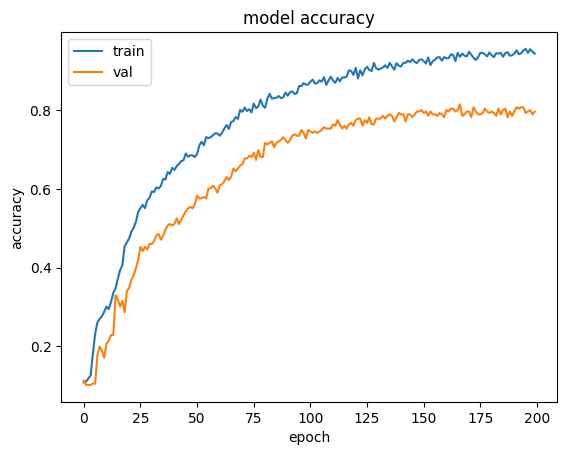

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

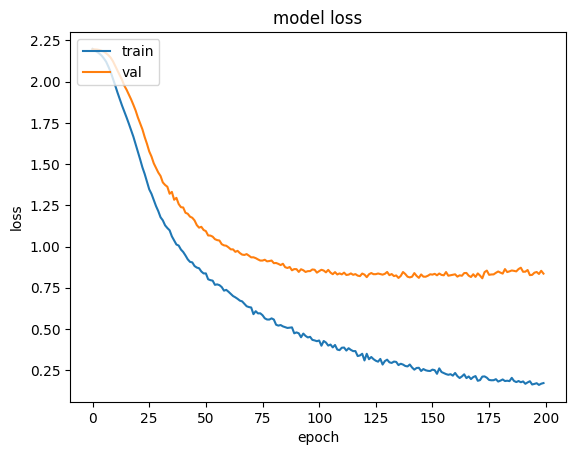

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
# Get the weights of the individual branch models
branch_weights = []

for branch_model in branch_models:
    branch_weights.append(branch_model.get_weights())

# # Print the weights for each branch
# for i, branch_weight in enumerate(branch_weights):
#     print(f"Weights for Branch {i + 1}:", branch_weight)

In [ ]:
# Get the weights of the main model
main_model_weights = model.get_weights()

# # Print the weights for each layer
# for layer_weights in main_model_weights:
#     print(layer_weights)

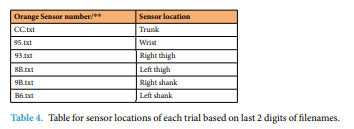

## Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import f1_score

# input_data = np.array(x_trains)

print("Evaluate on test data")
results = model.evaluate(x_tests, Y_9B_test, batch_size=128)
print("test loss, test acc:", results)


# # Generate predictions (probabilities -- the output of the last layer)
# # on new data using `predict`
# print("Generate predictions for 3 samples")
# predictions = model.predict(fft_x_tests, verbose=0)[:100]
# print("predictions shape:", predictions.shape)


#Predict
y_prediction = model.predict(x_tests)

#Create confusion matrix and normalizes it over predicted (columns)
y_prediction = np.argmax(y_prediction, axis=1)
print(y_prediction)
Y_9B_test_proc = np.argmax(Y_9B_test, axis=1)
print(Y_9B_test_proc)
result = confusion_matrix(Y_9B_test_proc, y_prediction , normalize='pred')

# Compute F1 score
f1 = f1_score(Y_9B_test_proc, y_prediction, average='weighted')

print("F1 score:", f1)

Evaluate on test data
2/2 [==============================] - 3s 31ms/step - loss: 0.6957 - accuracy: 0.8230
test loss, test acc: [0.6956848502159119, 0.8230452537536621]
8/8 [==============================] - 3s 17ms/step
[0 3 0 6 0 3 2 1 2 1 6 5 3 0 3 3 8 6 6 5 1 5 7 1 1 4 2 4 7 7 0 0 6 4 5 1 8
 1 3 0 6 6 5 7 2 3 3 3 8 0 3 5 3 0 4 6 4 0 7 3 6 2 0 8 4 1 1 8 6 6 0 5 5 4
 0 3 2 1 6 0 4 8 0 8 4 6 7 1 7 5 1 1 8 6 1 0 1 4 6 2 5 0 8 4 8 5 1 7 5 3 6
 1 5 4 6 1 8 8 5 6 8 2 8 6 3 4 8 0 8 4 1 5 1 1 4 4 1 5 2 7 3 5 5 8 3 4 7 7
 0 7 8 0 1 5 5 7 2 5 7 0 4 4 7 1 0 0 2 2 4 0 4 0 0 3 3 0 0 0 7 8 7 8 6 4 4
 4 1 8 7 8 6 4 3 3 4 1 3 7 6 3 4 0 7 6 6 4 5 8 5 2 7 2 4 4 3 5 3 3 6 0 4 7
 1 4 1 6 5 8 0 8 1 1 2 7 0 2 7 7 0 6 1 4 1]
[0 3 2 6 0 3 2 1 2 1 6 5 3 2 3 3 8 6 6 5 5 5 7 2 1 4 2 4 7 7 0 0 6 4 5 1 8
 1 3 0 6 6 5 7 2 3 3 3 8 3 2 5 3 0 4 6 4 4 7 3 6 2 0 8 4 5 1 8 6 6 0 5 5 4
 0 4 2 1 6 0 4 8 2 8 4 6 7 0 7 5 1 1 8 6 1 2 1 4 3 3 5 0 8 4 8 5 5 7 5 3 6
 1 7 4 6 1 8 8 5 6 8 2 8 6 3 8 8 0 8 4 1 4 1 1 4 4 1 5 2 7 

In [ ]:
# import numpy as np
# import tensorflow as tf

# def integrated_gradients(inputs, model, baseline=None, num_steps=50):
#     if baseline is None:
#         baseline = 0 * inputs

#     scaled_inputs = [baseline + (float(i) / num_steps) * (inputs - baseline) for i in range(num_steps + 1)]
#     scaled_inputs = tf.stack(scaled_inputs)

#     with tf.GradientTape() as tape:
#         tape.watch(scaled_inputs)
#         predictions = model(scaled_inputs)

#     grads = tape.gradient(predictions, scaled_inputs)
#     avg_grads = tf.reduce_mean(grads[:-1], axis=0)
#     integrated_grad = (inputs - baseline) * avg_grads
#     return integrated_grad.numpy()

# # Usage example:
# inputs = x_tests
# baseline = np.zeros_like(inputs)

# ig = integrated_gradients(inputs, model, baseline=baseline)

In [ ]:
# import numpy as np
# import cv2
# import tensorflow as tf
# from tensorflow.keras.models import Model

# def grad_cam(model, x, layer_name):
#     cls = np.argmax(model.predict(x))
#     with tf.GradientTape() as tape:
#         last_conv_layer = model.get_layer(layer_name)
#         iterate = Model([model.inputs], [model.output, last_conv_layer.output])
#         model_out, last_conv_layer = iterate(x)
#         grads = tape.gradient(model_out[:, cls], last_conv_layer)
#         pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
#     heatmap = tf.reduce_mean(tf.multiply(pooled_grads, last_conv_layer), axis=-1)
#     heatmap = np.maximum(heatmap, 0)
#     heatmap /= np.max(heatmap)
#     return heatmap

# # Usage example:
# heatmap = grad_cam(model, x_tests, layer_name='conv1d')  # Adjust layer_name to the appropriate layer in your model


In [ ]:
import matplotlib.pyplot as plt
import numpy
from sklearn import metrics

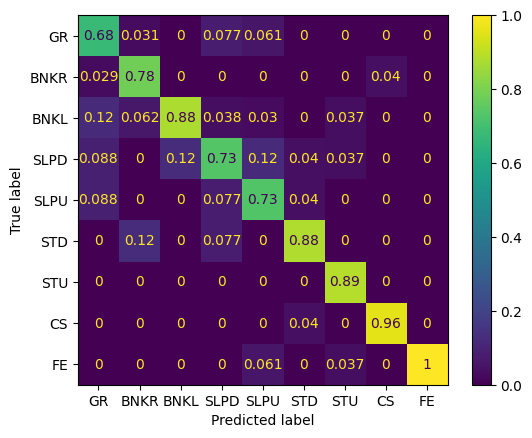

In [ ]:
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = result, display_labels = ['GR', 'BNKR', 'BNKL', 'SLPD', 'SLPU', 'STD', 'STU', 'CS', 'FE'])

cm_display.plot()
plt.show()

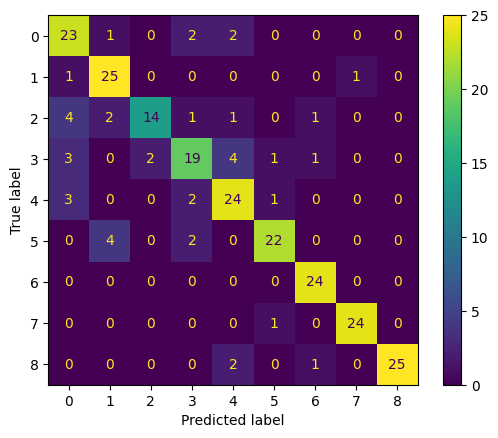

In [ ]:
ConfusionMatrixDisplay.from_predictions(Y_9B_test_proc, y_prediction)

In [ ]:
# 0 GR, 1 BNKR, 2 BNKL, 3 SLPD, 4 SLPU, 5 STD, 6 STU, 7 CS, 8 FE

In [ ]:
# 0 GR, 1 SLPD, 2 SLPU, 3 STD, 4 STU, 5 CS, 6 FE